# Продуктовая аналитика маркетплейса

## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа

### Иследование датасета


In [1]:
import pandas as pd
from operator import attrgetter
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import colors as mcolors
import numpy as np

In [2]:
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")

In [3]:
orders.isna().sum(), order_items.isna().sum(), customers.isna().sum()

(order_id                            0
 customer_id                         0
 order_status                        0
 order_purchase_timestamp            0
 order_approved_at                 160
 order_delivered_carrier_date     1783
 order_delivered_customer_date    2965
 order_estimated_delivery_date       0
 dtype: int64,
 order_id               0
 order_item_id          0
 product_id             0
 seller_id              0
 shipping_limit_date    0
 price                  0
 freight_value          0
 dtype: int64,
 customer_id                 0
 customer_unique_id          0
 customer_zip_code_prefix    0
 customer_city               0
 customer_state              0
 dtype: int64)

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
orders.groupby('order_status').order_id.nunique()

order_status
approved           2
canceled         625
created            5
delivered      96478
invoiced         314
processing       301
shipped         1107
unavailable      609
Name: order_id, dtype: int64

In [7]:
columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
orders[columns] = orders[columns].apply(pd.to_datetime)


In [8]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [9]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])

In [10]:
df_orders = orders.copy()
df_order_items = order_items.copy()
df_customers = customers.copy()


### Когортный анализ
#### Построить месячный retention 
В retention учитываем только доставленные заказы (status='delivered')

In [11]:
orders_delivered = orders[orders.order_status == 'delivered']
orders_delivered = orders_delivered.merge(customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left')

orders_delivered["order_month"] = orders_delivered['order_purchase_timestamp'].dt.to_period('M')
orders_delivered["order_day"] = orders_delivered['order_purchase_timestamp'].dt.to_period('D')

orders_delivered['cohort_month'] = orders_delivered.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
orders_delivered['cohort_day'] = orders_delivered.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

orders_delivered['period_number_month'] = np.floor((orders_delivered.order_day - orders_delivered.cohort_day).apply(attrgetter('n')) / 30)

In [12]:
df_cohort = orders_delivered.groupby(['cohort_month', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()

In [13]:
cohort_pivot = df_cohort.pivot_table(index='cohort_month', columns='period_number_month', values='n_customers')

cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix_percent = round(retention_matrix*100,2)
retention_matrix_percent

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.38,NaN,NaN,0.38,...,0.38,NaN,0.38,NaN,0.38,NaN,0.38,0.76,0.38,0.38
2016-12,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.28,NaN,0.56,0.14,0.14,0.28,0.28,NaN,NaN,...,0.56,0.42,0.28,NaN,0.28,0.28,0.28,0.14,NaN,NaN
2017-02,100.0,0.12,0.18,0.37,0.25,0.12,0.25,0.06,0.12,0.25,...,0.37,0.06,0.18,0.12,0.06,0.06,0.18,NaN,NaN,NaN
2017-03,100.0,0.28,0.52,0.44,0.12,0.08,0.36,0.16,0.24,0.24,...,0.16,0.16,0.12,0.28,0.08,0.12,0.08,NaN,NaN,NaN
2017-04,100.0,0.35,0.27,0.04,0.27,0.35,0.27,0.44,0.22,0.27,...,0.13,NaN,0.09,0.09,0.09,0.09,NaN,NaN,NaN,NaN
2017-05,100.0,0.41,0.41,0.23,0.38,0.32,0.32,0.12,0.29,0.26,...,0.32,0.17,0.09,0.20,0.12,NaN,NaN,NaN,NaN,NaN
2017-06,100.0,0.43,0.49,0.36,0.16,0.53,0.30,0.20,0.13,0.33,...,0.30,0.10,0.30,0.13,NaN,NaN,NaN,NaN,NaN,NaN


#### Проанализировать, чему равен медианный retention 1-го месяца <br> (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

In [14]:
retention_matrix_percent[1.0].median(skipna=True)

0.35

#### Найти когорту с самым высоким retention на 3-й месяц.

In [15]:
month3_best = retention_matrix_percent[3].idxmax()
month3_best_value = retention_matrix_percent[3].max()

month3_best, month3_best_value

(Period('2017-01', 'M'), 0.56)

### Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

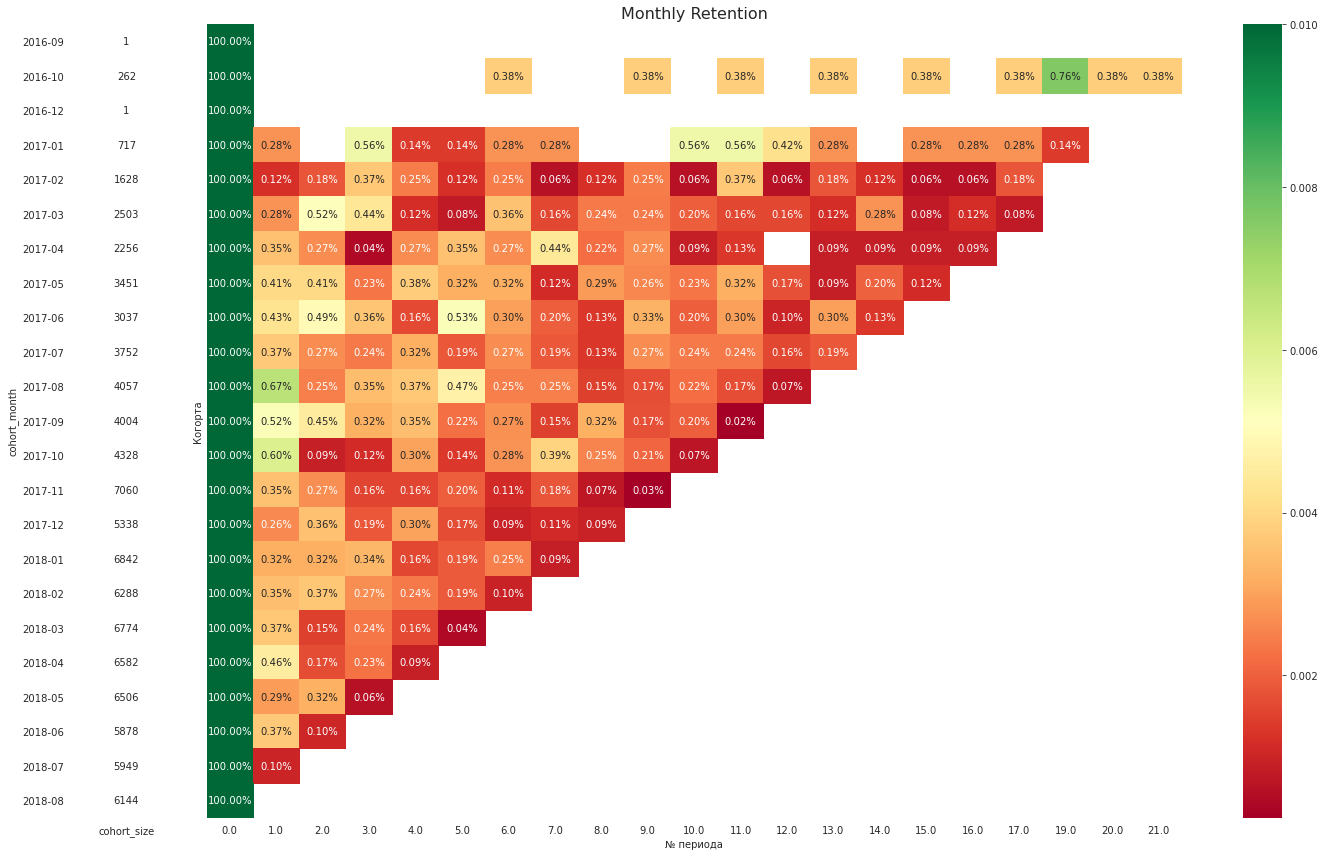

In [16]:
# Строим тепловую карту когортного анализа
# т.к. ретеншн низкий (<1%) - я адаптировала шкалу
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(20, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.2%',
                vmax=0.01,
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

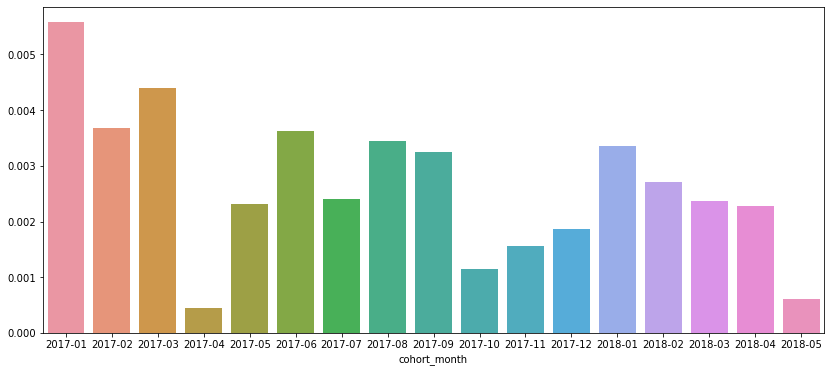

In [17]:
# Визуализация,что когорта 2017-01 действительно с самым высоким retention на 3-й месяц.
# *из тепловой карты это тоже видно
month3 = retention_matrix[3].dropna()
plt.figure(figsize=(14, 6))
sns.barplot(x=month3.index, y=month3.values)


## Задача 2. Определить, существует ли product/market fit у маркетплейса.

### Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.

PMF отсутсвует - почти все пользователи перестают пользоваться продуктом после первого заказа.

#### Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. <br>Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?

<p> Факты из когортного анализа:<br>
1) Резкое падение удержания после первой покупки (медианный retention 1-го месяца ≈ 0.35%)<br>
почти все клиенты не повторяют покупку. <br>
2) Почти полное отсутствие возвращения в последующие месяцы (у всех когорт возвращаемость < 1%) <br>
клиенты не формируют привычку возвращаться. <br>
3) Когорты ведут себя одинаково плохо (у всех когорт возвращаемость < 1%)<br>
Независимо от месяца первого заказа, ни одна когорта не показывает устойчивого удержания.<br>
Т.е. проблема не в сезонности </p>


<p> На чём сконцентрироваться:<br>
1) Понять причины отсутствия повторных заказов <br>
2) Проверить гипотезы, направленные на рост повторных покупок <br>
3) На удержании привлеченных, а не привлечении новых пользователей </p> 


<p> Возможные причины отсутсвия PMF: <br>
1) Узкий нерелевантный ассортимент <br>
2) Долгая и дорогая логистика <br>
3) Нет удерживающих механизмов (пушей, напоминаний после доставки, персональных рекомендаций, программы лояльности и др)<br>
4) неудобный UX </p> 

#### Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

In [18]:
pmf_median = retention_matrix_percent.median(skipna=True)
pmf_median

period_number_month
0.0     100.000
1.0       0.350
2.0       0.270
3.0       0.240
4.0       0.245
5.0       0.190
6.0       0.270
7.0       0.180
8.0       0.150
9.0       0.250
10.0      0.200
11.0      0.270
12.0      0.160
13.0      0.185
14.0      0.130
15.0      0.105
16.0      0.105
17.0      0.230
19.0      0.450
20.0      0.380
21.0      0.380
dtype: float64

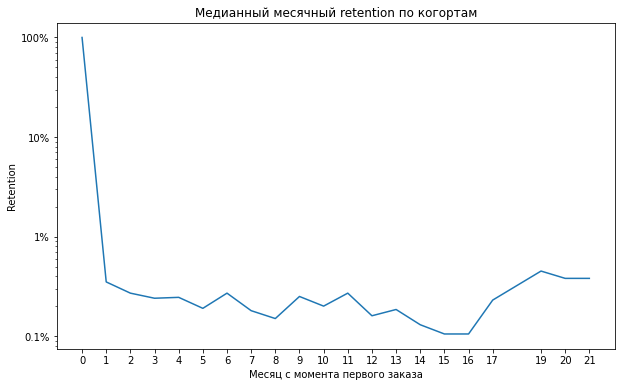

In [19]:
# шкала адаптирована (логарифмическая), чтобы отразить и 100% и 1%
# график показывает медианный процент возращаемости клиентов с течением времени
# видно, что он ниже 1% для всех когорт

plt.figure(figsize=(10, 6))

plt.plot(pmf_median.index, pmf_median.values)

plt.yscale('log')

ax = plt.gca()
ax.set_yticks([100, 10, 1, 0.1])
ax.set_yticklabels(['100%', '10%', '1%', '0.1%'])

plt.xticks(pmf_median.index)

plt.xlabel('Месяц с момента первого заказа')
plt.ylabel('Retention')
plt.title('Медианный месячный retention по когортам')

plt.show()


## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

#### 1. общий объём продаж (GMV) 
отражает рост объёма продаж маркетплейса

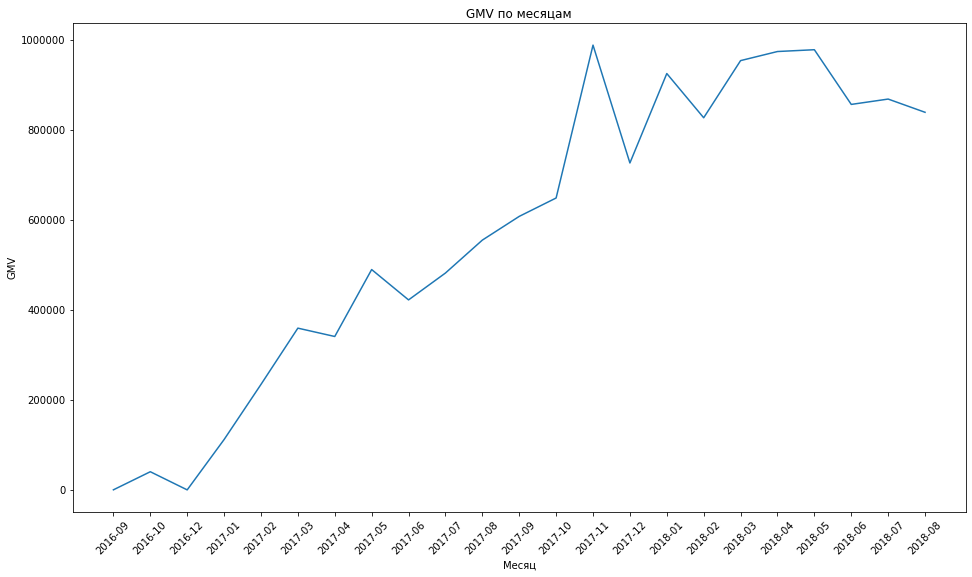

In [20]:
# расчет GMV
orders_items_merged = orders_delivered.merge(order_items[['order_id', 'price']], on='order_id', how='left')
gmv_monthly = (orders_items_merged.groupby('order_month')['price'].sum().reset_index(name='GMV'))
gmv_monthly['order_month'] = gmv_monthly['order_month'].astype(str)

plt.figure(figsize=(16, 9))
sns.lineplot(data=gmv_monthly, x='order_month', y='GMV')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')
plt.title('GMV по месяцам')
plt.xlabel('Месяц')
plt.ylabel('GMV')
plt.xticks(rotation=45)
plt.show()

#### 2. MAU 
показывеат объем аудитории, которой продукт доставляет ценность

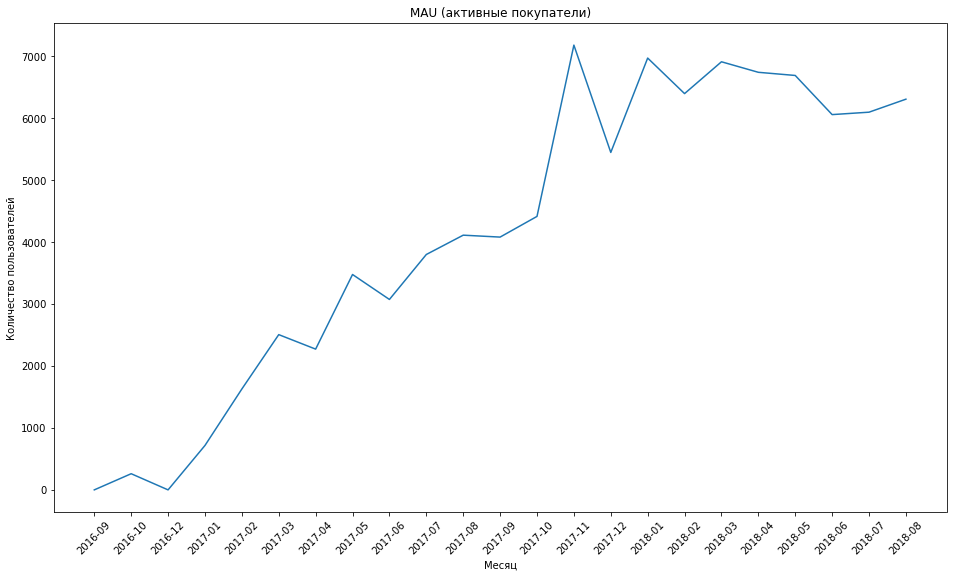

In [21]:
# MAU
mau = (orders_delivered.groupby('order_month')['customer_unique_id'].nunique().reset_index(name='MAU'))
mau.order_month = mau.order_month.astype(str)

plt.figure(figsize=(16, 9))
sns.lineplot(data=mau, x='order_month', y='MAU')
plt.title('MAU (активные покупатели)')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=45)
plt.show()

#### 3. CR в первую покупку
отражает заинтересованность новых клиентов в продукте

#### 4. Retention
отражает вовлеченность клиента в продолжение использования продукта

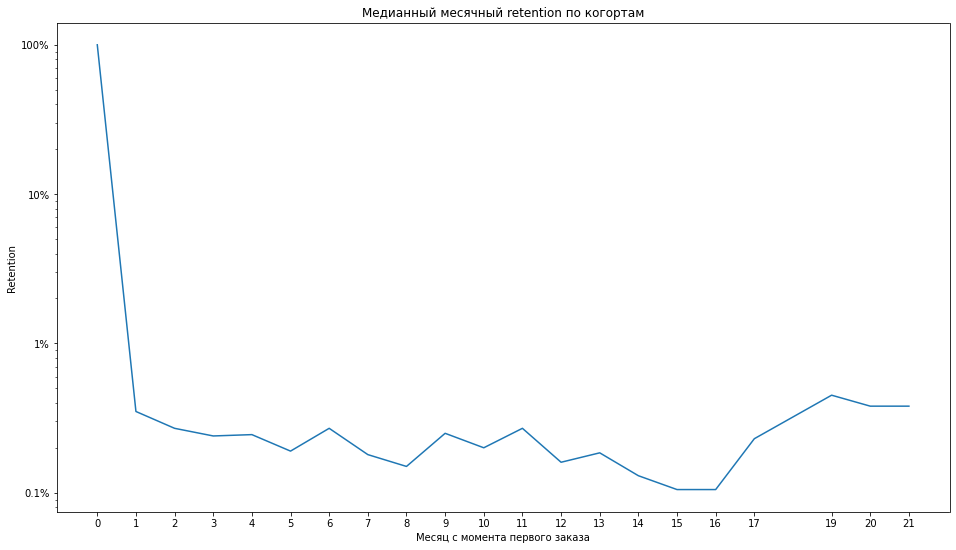

In [22]:
# retention - визуализация из 2 задания
plt.figure(figsize=(16, 9))

plt.plot(pmf_median.index, pmf_median.values)

plt.yscale('log')

ax = plt.gca()
ax.set_yticks([100, 10, 1, 0.1])
ax.set_yticklabels(['100%', '10%', '1%', '0.1%'])

plt.xticks(pmf_median.index)

plt.xlabel('Месяц с момента первого заказа')
plt.ylabel('Retention')
plt.title('Медианный месячный retention по когортам')

plt.show()


#### 5. ARPPU
отражает денежное выражение вовлеченности клиента

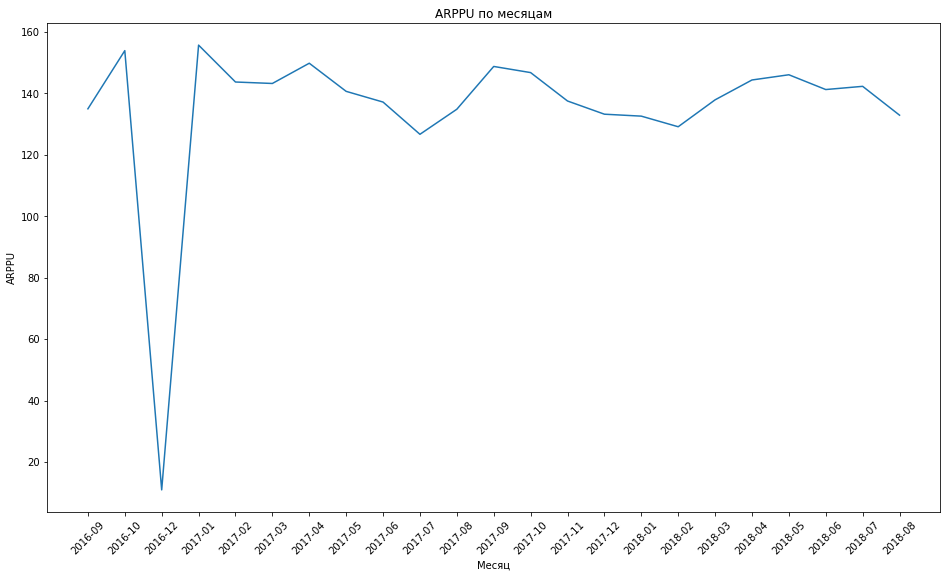

In [30]:
#ARPPU
arppu = gmv_monthly.merge(mau, on='order_month')
arppu['ARPPU'] = arppu['GMV'] / arppu['MAU']

plt.figure(figsize=(16, 9))
sns.lineplot(data=arppu, x='order_month', y='ARPPU')
plt.title('ARPPU по месяцам')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.xticks(rotation=45)
plt.show()

In [29]:
arppu

,order_month,GMV,MAU,ARPPU
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Для перевода метрики в Impact задана шкала; Confidence и Ease для трех гипотез тоже заданы

1) Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.
cancelled_orders = 974 -> impact = 5

In [26]:

after_june_2017 = orders[orders['order_purchase_timestamp'] >= '2017-06'].copy()
after_june_2017 = after_june_2017.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

CR = retention_matrix[1.0].median(skipna=True)

cancelled_orders = after_june_2017[after_june_2017.order_status.isin(['canceled', 'unavailable'])]['order_id'].nunique()

cancelled_orders

974

2) Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов. 
count_delayed*CR = 22 -> impact = 1

In [27]:
#запаздывания считаем
after_june_2017['order_delivery_day'] = after_june_2017['order_delivered_customer_date'].dt.to_period('D')
after_june_2017['order_estimated_day'] = after_june_2017['order_estimated_delivery_date'].dt.to_period('D')

count_delayed = after_june_2017[
    (after_june_2017.order_delivery_day > after_june_2017.order_estimated_day) & 
    (after_june_2017.order_status == 'delivered')
]['order_id'].nunique()

count_delayed*CR



21.585106382978722

3) Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов тех, кто раньше не делал повторный заказ.
single_order_customers_count*CR = 293 -> impact = 3

In [28]:
#after_june_2017 = after_june_2017.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
customer_order_counts = after_june_2017.groupby('customer_unique_id')['order_id'].nunique()
single_order_customers_count = (customer_order_counts == 1).sum()
single_order_customers_count*CR


292.76241134751774

Гипотеза 1: ICE = 5 * 8 * 6 = 240 <br>
Гипотеза 2: ICE = 1 * 10 * 4 = 40 <br>
Гипотеза 3: ICE = 3 * 5 * 9 = 135 <br>
Выбираем гипотезу с максимальным ICE - Гипотеза 1

## Задача 5. Сформулировать нужные метрики, на которые гипотеза должна повлиять.

Исходя из предыдущих вычислений была выбрана Гипотеза 1. Что исправление бага в системе процессинга заказов приведет к снижению количества отмен и увеличению количества доставленных заказов

#### Метрики:
**Целевая метрика:**<br>
— доля доставленных заказов <br>
Отражает напрямую бизнесс цели, были выбрана она, а не количество доставленных заказов, чтобы исключить сезонность и изменения трафика в подсчетах <br>

**Прокси-метрика:** <br>
— доля отменённых заказов <br>
Является прямым индикатором работы системы процессинга и позволяет быстрее зафиксировать эффект от исправления бага. Аналогично выбрана относительная метрика, а не абсолютное количество отмен, чтобы исключить влияние общего объёма заказов. <br>

**Guardrail-метрика:** <br>
— CR в оформление заказа <br>
Исправление бага не должно ухудшать пользовательский опыт и снижать конверсию в оформление заказа. Снижение данной метрики может указывать на негативное влияние изменений на воронку продаж.

## Задача 6. Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет.

#### Главная проблема продукта: он не закрывает потребности клиента 
Почему: низкая возвращаемость (пользователи делают только один заказ), отсутсвие PMF

Общие выводы:<br>
Несмотря на низкое удержание, общий объем продаж и количество активных пользователей в месяц растет. <br>
Средний чек держится на одном уровне.<br>
Анализ гипотез с помощью фреймворка ICE показал, что приоритетная гипотеза - устранение бага в процессинге заказа. <br>

<p> Рекомендации:
- исправить баги <br>
- исследовать целевую аудиторию и причины отказа от повторных покупок <br>
- проверить гипотезы по улучшению клиентского опыта во время и после доставки заказа <br>
- приоритизировать изменения, направленные на снижение отмен заказов и рост повторных покупок <br>
- после стабилизации базовых процессов тестировать механики удержания (персональные предложения, напоминания, программы лояльности)</p>
